In [1]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def objective_function(x):
    return x * np.sin(5 * x) + np.cos(2 * x)

def generate_neighbor(x, step_size=0.6):
    new_x = x + random.uniform(-step_size, step_size)
    return max(0, min(10, new_x))

def simulated_annealing_visual(initial_solution, initial_temp, cooling_rate, stopping_temp):
    S = initial_solution
    T = initial_temp
    
    # Lists to save history
    history_x = [S]
    history_y = [objective_function(S)]
    temperatures = [T]
    
    while T > stopping_temp:
        S_new = generate_neighbor(S)
        delta_E = objective_function(S) - objective_function(S_new)
        
        if delta_E < 0:
            S = S_new
            history_x.append(S)
            history_y.append(objective_function(S))
            temperatures.append(T)
        else:
            p = math.exp(-delta_E / T)
            if random.random() < p:
                S = S_new
                history_x.append(S)
                history_y.append(objective_function(S))
                temperatures.append(T)
                
        T = T * cooling_rate
        
    return history_x, history_y, temperatures


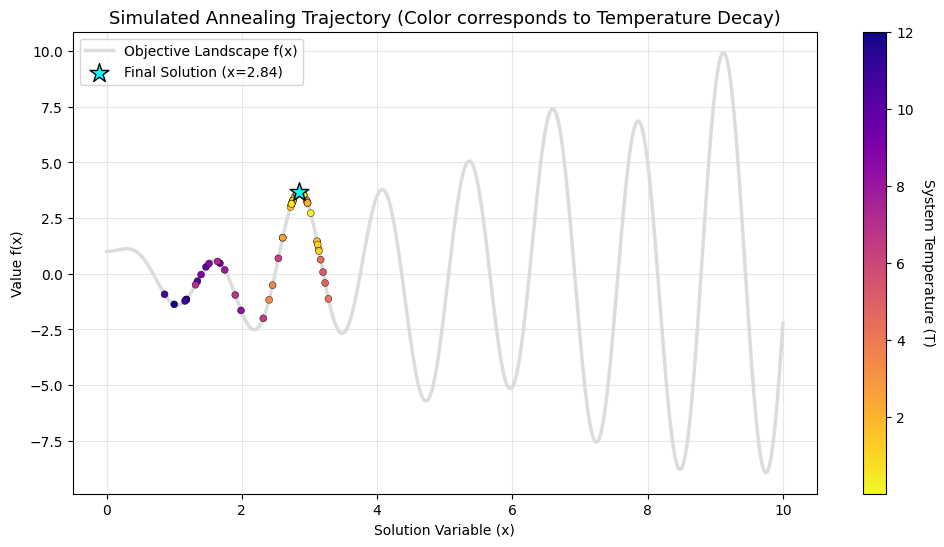

In [3]:
# Run the algorithm
hx, hy, temps = simulated_annealing_visual(initial_solution=1.0, initial_temp=12.0, cooling_rate=0.96, stopping_temp=0.01)

# Create Plot
x_landscape = np.linspace(0, 10, 1000)
y_landscape = objective_function(x_landscape)

plt.figure(figsize=(12, 6))

# Plot underlying function landscape
plt.plot(x_landscape, y_landscape, color='gainsboro', linewidth=2.5, label='Objective Landscape f(x)')

# Scatter the history of solutions colored by the temperature at that step
scatter = plt.scatter(hx, hy, c=temps, cmap='plasma_r', s=25, zorder=3, edgecolors='black', linewidths=0.3)
cbar = plt.colorbar(scatter)
cbar.set_label('System Temperature (T)', rotation=270, labelpad=15)

# Emphasize final solution
plt.scatter(hx[-1], hy[-1], color='cyan', marker='*', s=200, zorder=5, label=f'Final Solution (x={hx[-1]:.2f})', edgecolors='black')

plt.title('Simulated Annealing Trajectory (Color corresponds to Temperature Decay)', fontsize=13)
plt.xlabel('Solution Variable (x)')
plt.ylabel('Value f(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()